In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$. $\newline$
This section is based off Theorem 2.6 of the paper.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import mc

In [28]:
# We first define the constants
N = 1600
p_1 = 1/np.sqrt(2)
p_2 = 0.7
p_3 = 0.71

iteration_count = 4000
number_deltas = 50
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.

To estimate the optimal $m_1$ and $m_2$ we solve the equation $p \cdot m_1 + (1-p) \cdot m_2 = 0, \: m_1,m_2 \in \mathbb{Z}$

In [29]:
m_1_irrational, m_2_irrational = mc.find_opt_int(N, p_1)
m_1_rational, m_2_rational = mc.find_opt_int(N, p_2)
m_1_3, m_2_3 = mc.find_opt_int(N, p_3)

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}f(X_i) - \mathbb{E}[f(X)] |
\end{equation}

We know from 3.17 page 22 of the paper that for a rational p, we have that the supremum function is
\begin{equation}
f(x) = e^{\frac{2\pi i}{N}\sum\limits_{j=1}^{d}m_jx_j}
\end{equation}
with the constraint that $m_1, \dots, m_d \in \mathbb{Z}$ are not all zero and verify the property 
\begin{equation}
\sum\limits_{j=1}^{d}m_j(p_j-p_{-j}).
\end{equation}

In our case we have $m_1 \cdot p + m_2 \cdot(1-p) = 0$, and setting $p=0.7$ we obtain $0.7m_1 + 0.3m_2 = 0$ where we pick $m_1 = 3$ and $m_2 = -7$

\begin{equation}
\Delta_n = \sqrt{\mathbb{E}[\frac{1}{n^2}(\sum\limits_{k=0}^{n-1}cos(\frac{2\pi}{N}(m_1x_k+m_2y_k))^2 + (\sum\limits_{k=0}^{n-1}sin(\frac{2\pi}{N}(m_1x_k+m_2y_k)))^2)]}
\end{equation}

Note that we at first wondered what $X_0 \sim \mu$ meant in terms of simulation, and then realized that it meant that at every run, we randomly sample $(x_0, y_0) \sim \mathcal{U}[1,\dots,N]$ instead of starting from a fixed position for every run of the $\Delta_n$.

In [30]:
delta_n_1 = mc.compute_delta_paper(N, p_1, m_1_irrational, m_2_irrational, number_deltas, iteration_count) # sqrt
delta_n_3 = mc.compute_delta_paper(N, p_2, m_1_rational, m_2_rational, number_deltas, iteration_count) # rational
delta_n_4 = mc.compute_delta_paper(N, p_3, m_1_3, m_2_3, number_deltas, iteration_count) # rational

0.7071067811865475
0.7
0.71


In [31]:
print("Irrational m_1: ", m_1_irrational)
print("Irational m_2: ", m_2_irrational)
print("Rational m_1: ", m_1_rational)
print("Rational m_2: ", m_2_rational)

Irrational m_1:  1598
Irational m_2:  5
Rational m_1:  3
Rational m_2:  1593


Now we plot $\Delta_n$ for all the different transition probabilities

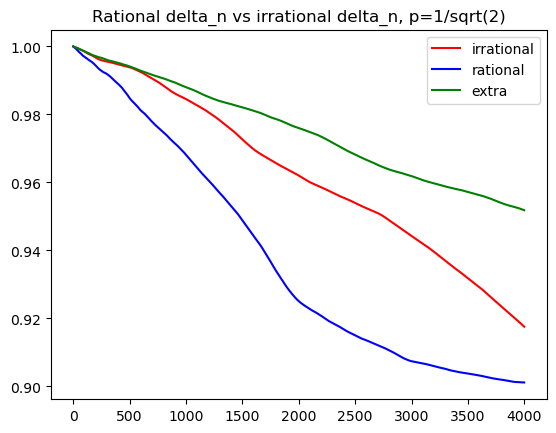

In [32]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_3, c="b", label="rational")
plt.plot(range(iteration_count), delta_n_4, c="g", label="extra")
plt.title("Rational delta_n vs irrational delta_n, p=1/sqrt(2)")
plt.legend()

We now estimate $\tau$. We do that by finding a constant such that $\tau \geq \frac{n\Delta_n^2}{4}, \forall n \geq 1$

In [61]:
tau_irrational = mc.compute_observed_tau(delta_n_1)
tau_irrational

np.float64(864.6610938050444)

In [62]:
tau_rational = mc.compute_observed_tau(delta_n_3)
tau_rational

np.float64(826.3230446582781)

Now we plot the different $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

/var/folders/22/_dymvqsd4tgfb0zzj_kpnj340000gn/T/ipykernel_9487/238708958.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]


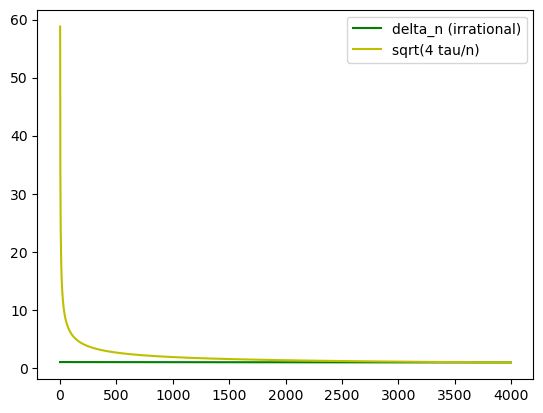

In [63]:
plt.plot(range(iteration_count), delta_n_1, c="g", label="delta_n (irrational)")
tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='y', label="sqrt(4 tau/n)")
plt.legend()

The $\Delta_n$ and $\tau$ computed above were found for $p_\text{rational} = 0.7$ and $p_\text{irrational} = \frac{1}{\sqrt 2}$. $\newline$ 
To observe if the constants scale with probabilities and if the convergence time of $\Delta_n$ is affected heavily by the transition probabilities, we now compute the same values for $p_\text{rational} = 0.35$ and $p_\text{irrational} = \frac{1}{\sqrt 8}$. $\newline$
We set $m_1 = -13, m_2 = 7$ to solve $m_1 \cdot 0.35 + m_2 \cdot 0.65 = 0$.

In [33]:
p_rational = 0.35
p_irrational = 1/np.sqrt(8)
m_1_rational, m_2_rational = mc.find_opt_int(N, p_rational)
m_1_irrational, m_2_irrational = mc.find_opt_int(N, p_irrational)

In [34]:
delta_n_irrational = mc.compute_delta_paper(N, p_irrational, m_1_irrational, m_2_irrational, number_deltas, iteration_count) 
delta_n_rational = mc.compute_delta_paper(N, p_rational, m_1_rational, m_2_rational, number_deltas, iteration_count) 

0.35355339059327373
0.35


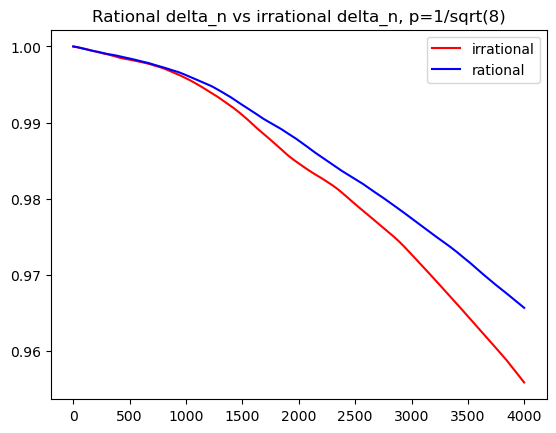

In [35]:
plt.plot(range(iteration_count), delta_n_irrational, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_rational, c="b", label="rational")
plt.title("Rational delta_n vs irrational delta_n, p=1/sqrt(8)")
plt.legend()

In [36]:
tau_small_irrational = mc.compute_observed_tau(delta_n_irrational)
tau_small_rational = mc.compute_observed_tau(delta_n_rational)
print("Irrational tau: ", tau_small_irrational)
print("Rational tau: ", tau_small_rational)

Irrational tau:  913.6713044055048
Rational tau:  932.5164272875338


We observe a sizeable difference between $\tau_\text{rational}$ and $\tau_\text{irrational}$! We now try again with even smaller p values.

In [37]:
p_irrational_2 = 1/np.sqrt(200)
p_rational_2 = 0.07
m_1_rational_2, m_2_rational_2 = mc.find_opt_int(N, p_rational_2)
m_1_irrational_2, m_2_irrational_2 = mc.find_opt_int(N, p_irrational_2)

In [39]:
print(m_1_irrational_2)

1587


In [40]:
print(m_2_irrational_2)

1


In [41]:
delta_n_irrational_2 = mc.compute_delta_paper(N, p_irrational_2, m_1_irrational_2, m_2_irrational_2, number_deltas, iteration_count) 
delta_n_rational_2 = mc.compute_delta_paper(N, p_rational_2, m_1_rational_2, m_2_rational_2, number_deltas, iteration_count) 

0.07071067811865475
0.07


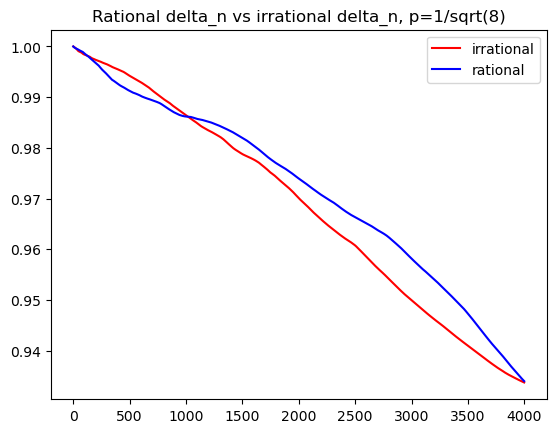

In [42]:
plt.plot(range(iteration_count), delta_n_irrational_2, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_rational_2, c="b", label="rational")
plt.title("Rational delta_n vs irrational delta_n, p=1/sqrt(8)")
plt.legend()

In [43]:
tau_small_irrational_2 = mc.compute_observed_tau(delta_n_irrational_2)
tau_small_rational_2 = mc.compute_observed_tau(delta_n_rational_2)
print("Irrational tau: ", tau_small_irrational)
print("Rational tau: ", tau_small_rational)

Irrational tau:  913.6713044055048
Rational tau:  932.5164272875338


We now compute the exact value of $\tau$.
We begin by computing the respective transition matrices $P_{rational}$ and $P_{irrational}$. For each matrix, respectively compute $L = I-P$ and then the second smallest singular value $\gamma$. As in the paper, we define the relaxation time of the chain by $\tau = \frac{1}{\gamma}$.

We tried to compute $\tau$ by directly creating a transition matrix and computing all the singular values but that did not work out very well because the transition matrix is $O(N^4)$ in storage relative to its input, and the algorithm to compute SVD values is $O(N^3)$ in its input, so all in all we would be looking at an $O(N^{12})$ time algorithm which, for N=100 already, is... huge.

So we used sparse matrices and scipy svds magic to make everything work, which took a bit of optimization work.

In [ ]:
# computations 
irrational_tau = mc.compute_tau(N, p_1)
rational_tau = mc.compute_tau(N, p_2) 
print("Rational tau for transition probabilities 0.7: ", irrational_tau)
print("Irrational tau for transition probabilities 1/sqrt(2): ", rational_tau)

In [ ]:
print("Rational tau: ", mc.compute_tau_cyclical(N, m_1_rational, m_2_rational, p_1))
print("Irrational tau: ", mc.compute_tau_cyclical(N, m_1_irrational, m_2_irrational, p_2))
print("Extra tau: ", mc.compute_tau_cyclical(N, m_1_irrational, m_2_irrational, p_3))

Rational tau:  388.1106662928938
Irrational tau:  409.6232279209636


In [ ]:
p_rational = 0.35
p_irrational = 1/np.sqrt(8)
theoretical_small_rational_tau = mc.compute_tau(N, p_rational)
theoretical_small_irrational_tau = mc.compute_tau(N, p_irrational)

print("Rational tau for transition probability 0.35: ", theoretical_small_rational_tau)
print("Irrational tau for transition probability 1/sqrt(8): ", theoretical_small_irrational_tau)

Rational tau for transition probability 0.35:  197.4065141745608
Irrational tau for transition probability 1/sqrt(8):  181.48909754319084


In [38]:
p_rational = 0.35
p_irrational = 1/np.sqrt(8)
theoretical_small_rational_tau = mc.compute_tau_cyclical(N, m_1_rational, m_2_rational, p_rational)
theoretical_small_irrational_tau = mc.compute_tau_cyclical(N, m_1_irrational, m_2_irrational, p_irrational)

print("Rational tau for transition probability 0.35: ", theoretical_small_rational_tau)
print("Irrational tau for transition probability 1/sqrt(8): ", theoretical_small_irrational_tau)

Rational tau for transition probability 0.35:  5077.092412367408
Irrational tau for transition probability 1/sqrt(8):  4189.020729827568


Now we simulate the value of $\tau$ as N grows for both $p=\frac{1}{\sqrt{2}}$ and $p = \frac{1}{2}$, in order to show whether there is a difference in curve smoothness to show different orders of magnitudes for each case.

In [ ]:
N_values = range(20, 100)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    rational_tau_list.append(mc.compute_tau(N, rational_p))
    irrational_tau_list.append(mc.compute_tau(N, irrational_p))
    print("tau number ", N, " finished computing")

Text(0, 0.5, 'tau')

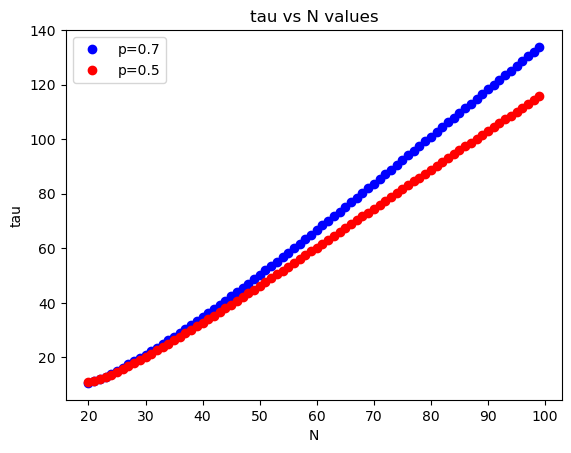

In [19]:
plt.plot(N_values, rational_tau_list, "o", c="b", label="p=0.7")
plt.plot(N_values, irrational_tau_list, "o", c="r", label="p=0.5")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")

In [ ]:
N_values = range(101, 150)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    rational_tau_list.append(mc.compute_tau(N, rational_p))
    irrational_tau_list.append(mc.compute_tau(N, irrational_p))
    print("tau number ", N, " finished computing")

Text(0, 0.5, 'tau')

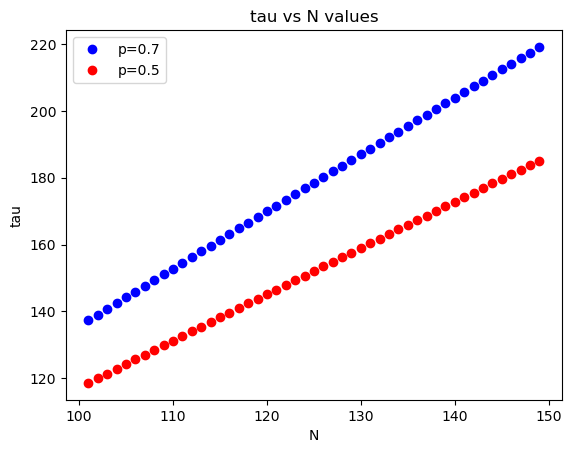

In [21]:
plt.plot(N_values, rational_tau_list, "o", c="b", label="p=0.7")
plt.plot(N_values, irrational_tau_list, "o", c="r", label="p=0.5")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")

In [22]:
N_values = range(300, 600)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    m_1_irrational, m_2_irrational = mc.find_opt_int(N, irrational_p)
    m_1_rational, m_2_rational = mc.find_opt_int(N, rational_p)
    rational_tau_list.append(mc.compute_tau_cyclical(N, m_1_rational, m_2_rational, rational_p))
    irrational_tau_list.append(mc.compute_tau_cyclical(N, m_1_irrational, m_2_irrational, irrational_p))
    print("tau number ", N, " finished computing")

tau number  300  finished computing
tau number  301  finished computing
tau number  302  finished computing
tau number  303  finished computing
tau number  304  finished computing
tau number  305  finished computing
tau number  306  finished computing
tau number  307  finished computing
tau number  308  finished computing
tau number  309  finished computing
tau number  310  finished computing
tau number  311  finished computing
tau number  312  finished computing
tau number  313  finished computing
tau number  314  finished computing
tau number  315  finished computing
tau number  316  finished computing
tau number  317  finished computing
tau number  318  finished computing
tau number  319  finished computing
tau number  320  finished computing
tau number  321  finished computing
tau number  322  finished computing
tau number  323  finished computing
tau number  324  finished computing
tau number  325  finished computing
tau number  326  finished computing
tau number  327  finished co

Text(0, 0.5, 'tau')

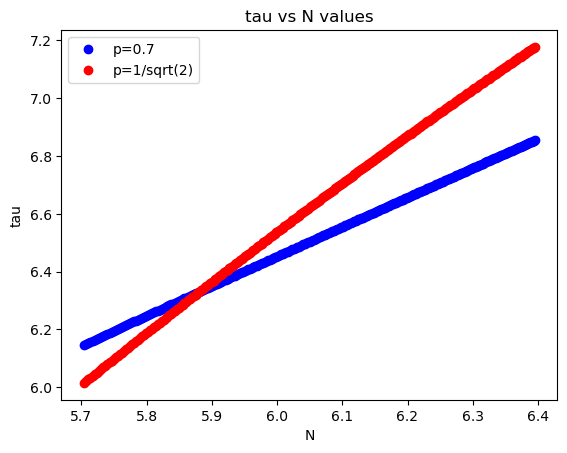

In [23]:
plt.plot(np.log(N_values), np.log(rational_tau_list), "o", c="b", label="p=0.7")
plt.plot(np.log(N_values), np.log(irrational_tau_list), "o", c="r", label="p=1/sqrt(2)")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")